In [1]:
import pandas as pd
import csv

# Re-read the file correctly
# The original error 'ParserError: Error tokenizing data. C error: EOF inside string'
# indicates a malformed CSV, likely with unescaped quotes or newlines within fields.
# Using the 'python' engine is more robust for such cases.
# 'on_bad_lines='warn'' will issue warnings for problematic lines rather than failing.
df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')

# Drop the 'Unnamed: 0' index column if it exists
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

# Combine title and text into 'content' like you did before
df['content'] = df['title'].fillna('') + " " + df['text'].fillna('')

# Keep only what you need
df = df[['content', 'label']]

# Ensure 'label' column is numeric and handle potential non-numeric entries
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

/tmp/ipykernel_1116/604459497.py:9: ParserWarning: Skipping line 329: field larger than field limit (131072)

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_1116/604459497.py:9: ParserWarning: Skipping line 6464: field larger than field limit (131072)

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_1116/604459497.py:9: ParserWarning: Skipping line 7373: unexpected end of data

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_1116/604459497.py:9: ParserWarning: Skipping line 335: Expected 4 fields in line 335, saw 6

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_1116/604459497.py:9: ParserWarning: Skipping line 6463: Expected 4 fields in line 6463, saw 7

  df = pd.read_csv('WELFake_Dataset.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_1116/604459497.py:9: ParserWarning: Skipping line 6

In [2]:
print(df.head())
print(df.columns)

                                             content  label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1
1     Did they post their votes for Hillary already?      1
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...      1
3  Bobby Jindal, raised Hindu, uses story of Chri...      0
4  SATAN 2: Russia unvelis an image of its terrif...      1
Index(['content', 'label'], dtype='object')


In [3]:
import re
import string

def preprocess_text(text):
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(f'[{re.escape(string.digits)}]', '', text)
    return text.strip()

# Now run your function
df['processed_content'] = df['content'].apply(preprocess_text)

# Check the result
df[['content', 'processed_content']].head()

,content,processed_content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...
1,Did they post their votes for Hillary already?,did they post their votes for hillary already
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama’s attorney general says mos...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu uses story of christ...
4,SATAN 2: Russia unvelis an image of its terrif...,satan russia unvelis an image of its terrifyi...


In [4]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(f'[{re.escape(string.digits)}]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7322 entries, 0 to 7343
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   content            7322 non-null   object
 1   label              7322 non-null   int64 
 2   processed_content  7322 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.8+ KB


,label
count,7322.000000
mean,0.527998
std,0.499250
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [6]:
df['label'].value_counts()

,count
label,
1,3866
0,3456


<Axes: >

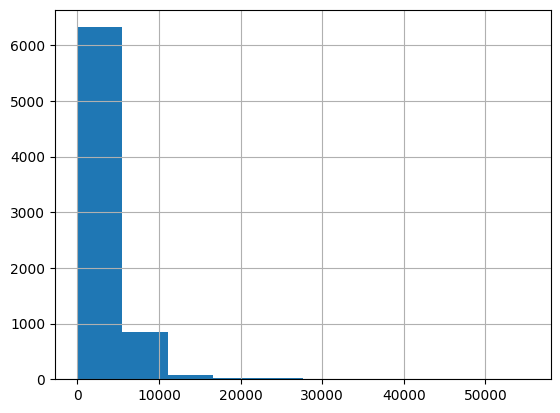

In [7]:
df['length'] = df['processed_content'].apply(len)

df['length'].hist()

In [8]:
from collections import Counter

all_words = " ".join(df['processed_content']).split()
Counter(all_words).most_common(20)

[('the', 224467),
 ('to', 115174),
 ('of', 101154),
 ('and', 92889),
 ('a', 89887),
 ('in', 77118),
 ('that', 52299),
 ('is', 38693),
 ('for', 37750),
 ('on', 37424),
 ('it', 26205),
 ('he', 25965),
 ('with', 25905),
 ('was', 24698),
 ('as', 24074),
 ('said', 23345),
 ('by', 20300),
 ('trump', 20063),
 ('s', 19323),
 ('his', 19051)]

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

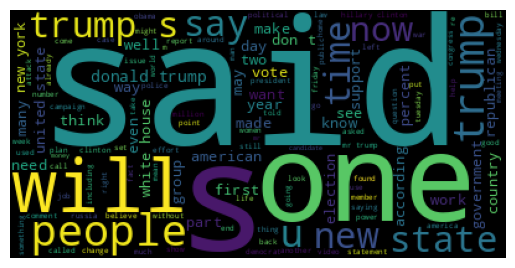

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud().generate(" ".join(df['processed_content']))
plt.imshow(wordcloud)
plt.axis("off")

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['processed_content'])
y = df['label']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Ensure processed_content exists
if 'processed_content' not in df.columns:
    df['processed_content'] = df['content'].apply(preprocess_text)

# 1. Features and Target
X = df['processed_content']
y = df['label']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Vectorize
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

# 4. Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 5. Predict
y_pred = model.predict(X_test_tfidf)

# 6. Results table
label_map = {0: 'Fake', 1: 'Real'}
results_df = pd.DataFrame({
    'Actual_Text_Snippet': X_test.str[:100] + "...",
    'True_Label':      [label_map[i] for i in y_test],
    'Predicted_Label': [label_map[i] for i in y_pred]
})

# 7. Display
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\n--- Predicted vs. True Labels ---")
print(results_df.head(15).to_string(index=False))

Model Accuracy: 90.44%

--- Predicted vs. True Labels ---
                                                                                     Actual_Text_Snippet True_Label Predicted_Label
 egyptian rights lawyer says hell run for president in  cairo reuters  egyptian human rights lawyer a...       Fake            Fake
 the trump camp just lied through its teeth about an assassination attempt on trump video while campa...       Real            Real
 donald trump vows to rip up trade deals and confront china  the new york times monessen pa  —   dona...       Fake            Fake
 things the media won’t tell you about “oppressed” antiamerican nfl qb colin kaepernick san fransisco...       Real            Real
 watch fox news host defends slavery in bizarre rant fox news  most popular prime time host bill o re...       Real            Real
 theyre going after arpaio because he was one of the first politicians to support trump and their now...       Real            Real
 trump backs surve

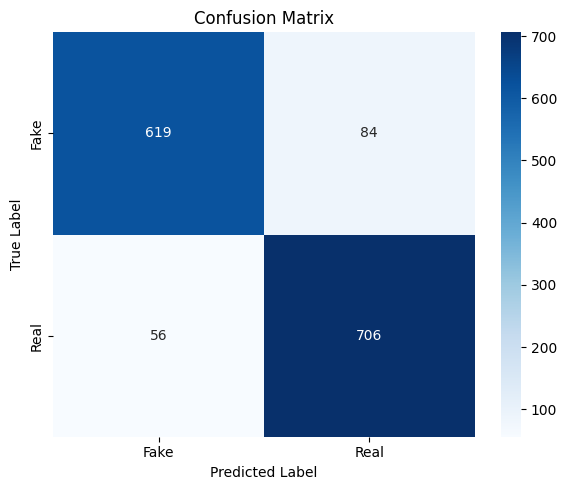

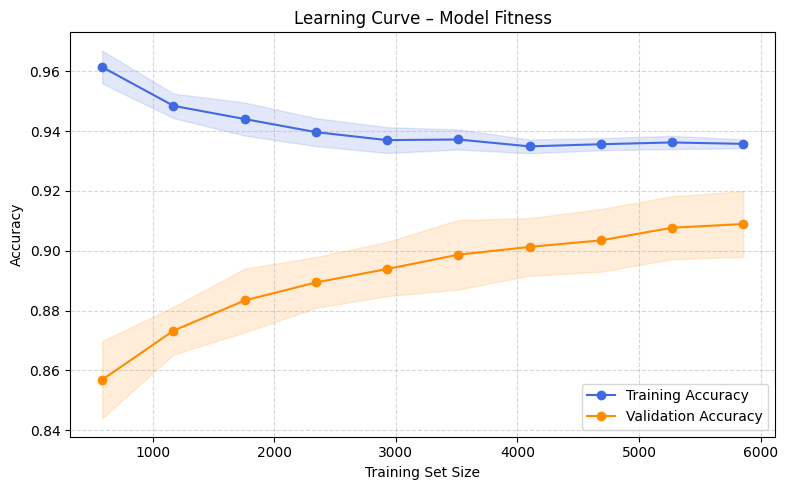

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import learning_curve
import numpy as np

# ── 1. Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 2. Learning Curve (Model Fitness) ────────────────────────────────
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf',   LogisticRegression(max_iter=1000))
])

train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue',  label='Training Accuracy')
plt.plot(train_sizes, val_mean,   'o-', color='darkorange', label='Validation Accuracy')

plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='royalblue')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='darkorange')

plt.title('Learning Curve – Model Fitness')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()

The confusion matrix indicates that the model correctly classifies most of the news articles, with relatively fewer misclassifications. The learning curve shows that training and validation accuracy converge, suggesting that the model generalizes well and does not suffer from severe overfitting.

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       703
           1       0.89      0.93      0.91       762

    accuracy                           0.90      1465
   macro avg       0.91      0.90      0.90      1465
weighted avg       0.90      0.90      0.90      1465



In [14]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9044368600682594


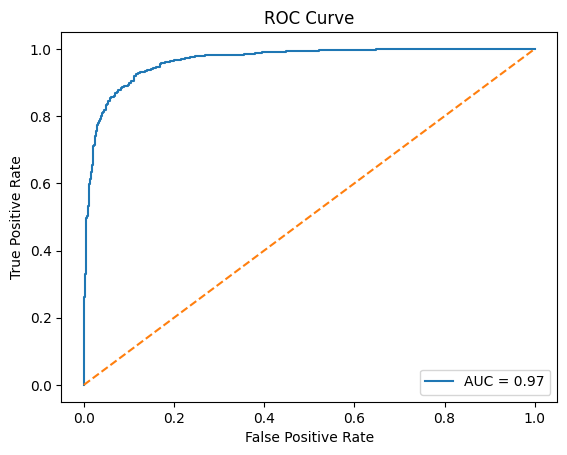

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Ensure processed_content exists (from cell FgQq9bJHmhBs)
# Assuming df is available in the kernel state
if 'processed_content' not in df.columns:
    import re
    import string
    def preprocess_text(text):
        text = text.lower()
        text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
        text = re.sub(f'[{re.escape(string.digits)}]', '', text)
        return text.strip()
    df['processed_content'] = df['content'].apply(preprocess_text)

# Define X and y (from cell FgQq9bJHmhBs)
X = df['processed_content']
y = df['label']

# Split the data into training and testing sets (from cell FgQq9bJHmhBs)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the pipeline (from cell 2tKarjv7mkzY)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf',   LogisticRegression(max_iter=1000))
])

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Now predict probabilities for the ROC curve
y_prob = pipeline.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [16]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coefficients = pipeline.named_steps['clf'].coef_[0]

# Top words for REAL
top_real = sorted(zip(coefficients, feature_names), reverse=True)[:10]

# Top words for FAKE
top_fake = sorted(zip(coefficients, feature_names))[:10]

print("Top words indicating REAL news:")
for coef, word in top_real:
    print(word, coef)

print("\nTop words indicating FAKE news:")
for coef, word in top_fake:
    print(word, coef)

Top words indicating REAL news:
video 5.001410704162007
via 4.2774887265322326
hillary 4.064464249622672
this 3.6198128033525427
image 3.2546949062060673
just 2.530164165659828
obama 2.512502007502593
is 2.3864317714329157
october 2.3829266605618096
fbi 2.154153494108316

Top words indicating FAKE news:
said -10.657531749675062
reuters -8.507260331899216
breitbart -5.041474787110619
on -4.538461589427147
mr -4.386745695991947
twitter -2.7728622137166363
follow -2.7588638231027547
in -2.646086937214766
thursday -2.5064308840180334
new -2.412905448703464


Prediction: Real
Confidence - Fake: 34.12%  |  Real: 65.88%


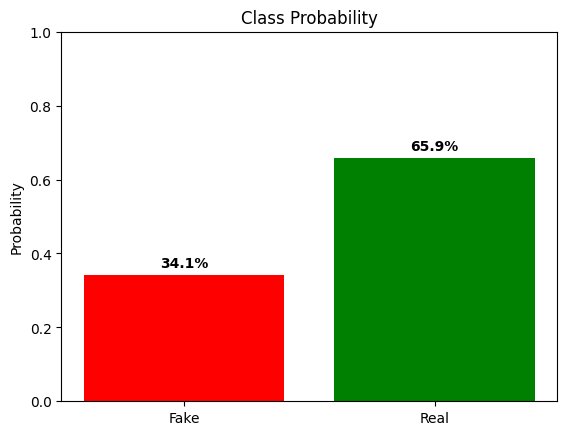

In [17]:
sample = df['content'].iloc[0]

# Get probabilities instead of just label
proba = pipeline.predict_proba([sample])[0]
prediction = pipeline.predict([sample])[0]
label_map = {0: 'Fake', 1: 'Real'}

print(f"Prediction: {label_map[prediction]}")
print(f"Confidence - Fake: {proba[0]*100:.2f}%  |  Real: {proba[1]*100:.2f}%")

# Bar chart of class probabilities
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.bar(['Fake', 'Real'], proba, color=['red', 'green'])
ax.set_ylabel('Probability')
ax.set_title('Class Probability')
ax.set_ylim(0, 1)
for i, v in enumerate(proba):
    ax.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')
plt.show()

In [24]:
import joblib

joblib.dump(pipeline, "logistic_model.pkl")

['logistic_model.pkl']

In [25]:
from google.colab import files
files.download("logistic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>